# **Name: MD ABU SAYEM**
# **Roll: 25/SET/MTCE/014**

# **Experiment_3A: Student Performance Prediction Using Simple Linear Regression**

A study is conducted to analyze the relationship between the number of hours studied (X) and the corresponding exam scores (Y) of students using Simple Linear Regression.

The dataset is given below:

Hours Studied (X) | Exam Score (Y)
-----------------|---------------
2                | 55
3                | 60
5                | 65
6                | 70
8                | 80
9                | 85


Tasks:

1. Fit a Simple Linear Regression model and calculate:

    Slope

    Intercept

2. Predict the exam score of a student who studied for 7 hours.

3. Compute the p-value and test whether the relationship between hours studied and exam score is statistically significant.

4. Calculate the residuals (error = actual − predicted).

5. Plot:

    Regression line with data points

    Histogram of residuals

6. Check whether the residuals follow a normal (bell-shaped) distribution.

7. Perform:

    Shapiro–Wilk test for normality

    Durbin–Watson test for autocorrelation

8. Interpret all results.

In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from scipy import stats
from scipy.stats import gaussian_kde, norm
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy.stats import norm

In [76]:
# Dataset
X = np.array([2, 3, 5, 6, 8, 9])
Y = np.array([55, 60, 65, 70, 80, 85])

data = pd.DataFrame({
    "Hours_Studied": X,
    "Exam_Score": Y
})

print("Dataset:")
print(data)

Dataset:
   Hours_Studied  Exam_Score
0              2          55
1              3          60
2              5          65
3              6          70
4              8          80
5              9          85


In [77]:
X_const = sm.add_constant(X)   # add intercept
model = sm.OLS(Y, X_const).fit()

print("\nRegression Summary:")
print(model.summary())


Regression Summary:
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.986
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                     283.5
Date:                Sun, 01 Feb 2026   Prob (F-statistic):           7.29e-05
Time:                        14:12:48   Log-Likelihood:                -9.8391
No. Observations:                   6   AIC:                             23.68
Df Residuals:                       4   BIC:                             23.26
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         46.0667      1.50

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [78]:
# Slope & Intercept
intercept = model.params[0]
slope = model.params[1]

print(f"\nIntercept (β0): {intercept:.4f}")
print(f"Slope (β1): {slope:.4f}")


Intercept (β0): 46.0667
Slope (β1): 4.2000


In [79]:
# Prediction for 7 hours
hours = 7
predicted_score = intercept + slope * hours

print(f"\nPredicted Exam Score for 7 hours of study: {predicted_score:.2f}")


Predicted Exam Score for 7 hours of study: 75.47


In [80]:
# Residuals
predicted_Y = model.predict(X_const)
residuals = Y - predicted_Y

print("\nResiduals:")
print(residuals)


Residuals:
[ 0.53333333  1.33333333 -2.06666667 -1.26666667  0.33333333  1.13333333]


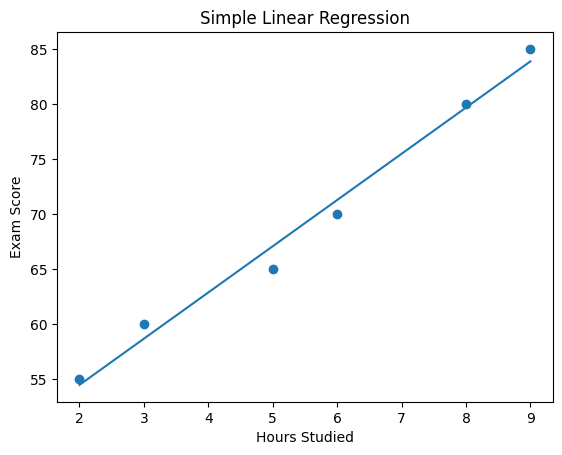

In [81]:
# Regression Plot
plt.figure()
plt.scatter(X, Y)
plt.plot(X, predicted_Y)
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Simple Linear Regression")
plt.show()

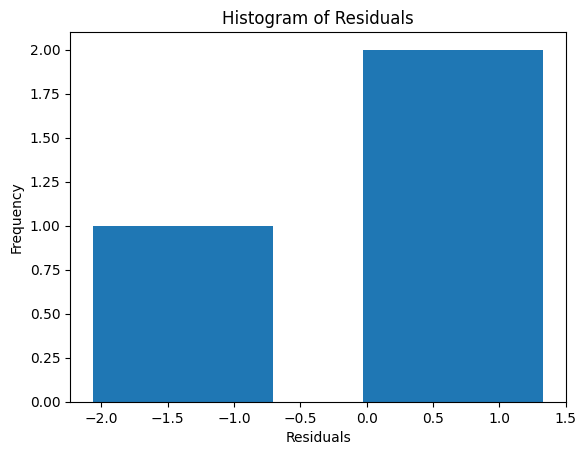

In [82]:
# Histogram of Residuals
plt.figure()
plt.hist(residuals, bins=5)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")
plt.show()

In [83]:
# Normality Test (Shapiro-Wilk)
shapiro_stat, shapiro_p = stats.shapiro(residuals)

print("\nShapiro-Wilk Test:")
print(f"Statistic: {shapiro_stat:.4f}")
print(f"P-value: {shapiro_p:.4f}")


Shapiro-Wilk Test:
Statistic: 0.8871
P-value: 0.3034


In [84]:
# Durbin-Watson Test
dw_stat = durbin_watson(residuals)

print("\nDurbin-Watson Test:")
print(f"DW Statistic: {dw_stat:.4f}")


Durbin-Watson Test:
DW Statistic: 1.7186


In [85]:
# Add constant for intercept
X_const = sm.add_constant(X)
# Fit regression model
model = sm.OLS(Y, X_const).fit()
# Extract p-value of slope (β1)
p_value = model.pvalues[1]
alpha = 0.05  # significance level
print(f"P-value of slope (β1): {p_value:.6f}")

P-value of slope (β1): 0.000073


In [86]:
# Decision based on p-value
if p_value < alpha:
    print("\nDecision:")
    print("Reject the Null Hypothesis (H0)")
    print("There is a STRONG and STATISTICALLY SIGNIFICANT relationship")
    print("Hours studied significantly affects exam score")
else:
    print("\nDecision:")
    print("Fail to Reject the Null Hypothesis (H0)")
    print("No statistically significant relationship found")


Decision:
Reject the Null Hypothesis (H0)
There is a STRONG and STATISTICALLY SIGNIFICANT relationship
Hours studied significantly affects exam score


In [87]:
# Residuals & Fitted values
fitted = model.predict(X_const)
residuals = Y - fitted

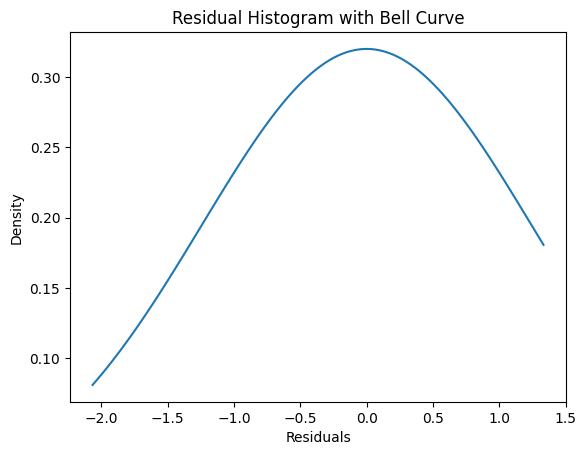

In [88]:
# Bell curve (Normal PDF)
mu, sigma = np.mean(residuals), np.std(residuals)
x = np.linspace(min(residuals), max(residuals), 100)
plt.plot(x, stats.norm.pdf(x, mu, sigma))

plt.title("Residual Histogram with Bell Curve")
plt.xlabel("Residuals")
plt.ylabel("Density")
plt.show()

<Figure size 600x400 with 0 Axes>

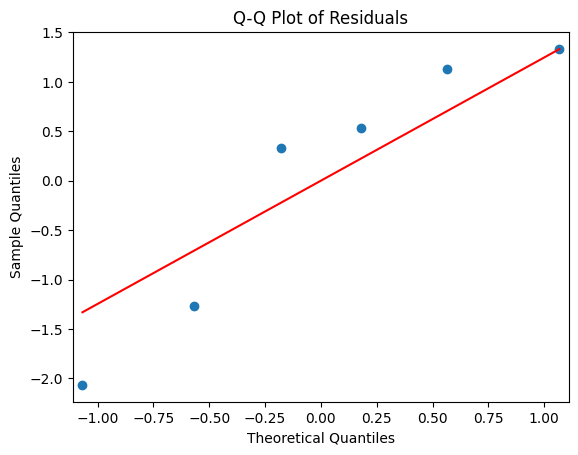

In [89]:
# Q-Q Plot (Normality)
plt.figure(figsize=(6,4))
sm.qqplot(residuals, line='s')
plt.title("Q-Q Plot of Residuals")
plt.show()

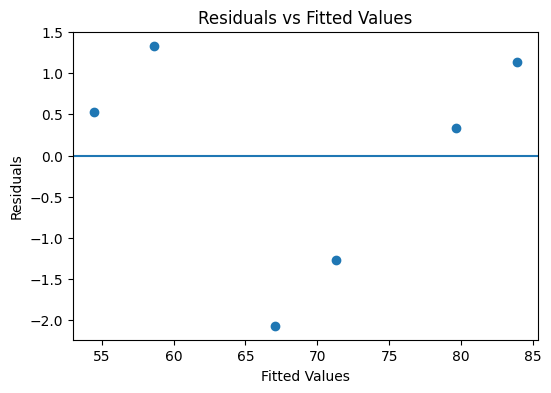

In [90]:
# Residuals vs Fitted (Homoscedasticity visual)
plt.figure(figsize=(6,4))
plt.scatter(fitted, residuals)
plt.axhline(0)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

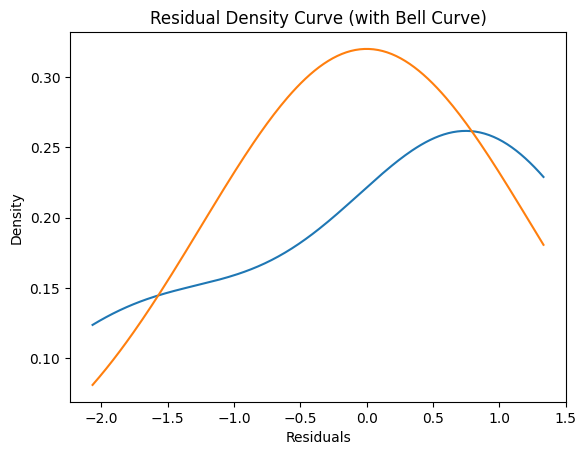

In [91]:
# Smooth KDE curve
kde = gaussian_kde(residuals)
x_vals = np.linspace(min(residuals), max(residuals), 200)
plt.plot(x_vals, kde(x_vals))

# Normal (bell) curve for comparison
mu, sigma = np.mean(residuals), np.std(residuals)
plt.plot(x_vals, norm.pdf(x_vals, mu, sigma))

plt.title("Residual Density Curve (with Bell Curve)")
plt.xlabel("Residuals")
plt.ylabel("Density")
plt.show()

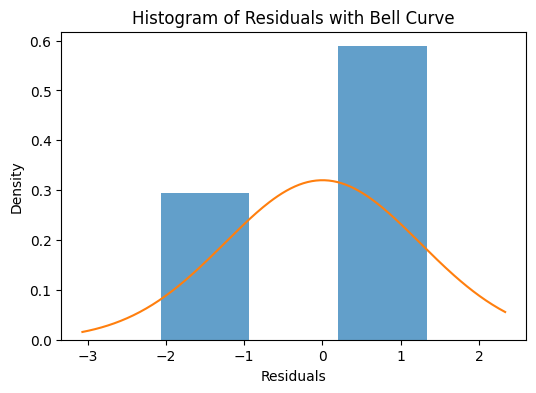

In [92]:
# Residuals
residuals = model.resid

plt.figure(figsize=(6,4))

# Histogram of residuals
plt.hist(residuals, bins=3, density=True, alpha=0.7)

# Normal bell curve
mu = np.mean(residuals)
sigma = np.std(residuals)

x = np.linspace(min(residuals)-1, max(residuals)+1, 200)
plt.plot(x, norm.pdf(x, mu, sigma))

plt.xlabel("Residuals")
plt.ylabel("Density")
plt.title("Histogram of Residuals with Bell Curve")
plt.show()

In [93]:
# Breusch-Pagan Test (Homoscedasticity)
bp_test = het_breuschpagan(residuals, X_const)
bp_pvalue = bp_test[1]

print("Breusch-Pagan Test:")
print(f"P-value: {bp_pvalue:.6f}")

if bp_pvalue > 0.05:
    print("Homoscedasticity satisfied (constant variance)")
else:
    print("Heteroscedasticity detected")

Breusch-Pagan Test:
P-value: 0.811084
Homoscedasticity satisfied (constant variance)


In [94]:
# Shapiro-Wilk Test (Normality)
shapiro_stat, shapiro_p = stats.shapiro(residuals)

print("\nShapiro-Wilk Test:")
print(f"P-value: {shapiro_p:.6f}")

if shapiro_p > 0.05:
    print("Residuals are normally distributed")
else:
    print("Residuals are NOT normally distributed")


Shapiro-Wilk Test:
P-value: 0.303374
Residuals are normally distributed


In [95]:
fitted_values = predicted_Y
residuals = Y - fitted_values

# Sort by fitted values
sorted_idx = np.argsort(fitted_values)
sorted_fitted = fitted_values[sorted_idx]
sorted_residuals = residuals[sorted_idx]

# Split into low & high fitted values
mid = len(sorted_fitted) // 2
low_residuals = sorted_residuals[:mid]
high_residuals = sorted_residuals[mid:]

# Variance calculation
var_low = np.var(low_residuals)
var_high = np.var(high_residuals)

# Homoscedasticity Factor
HF = var_low / var_high if var_high != 0 else np.inf

print("Variance (Low fitted values):", round(var_low, 4))
print("Variance (High fitted values):", round(var_high, 4))
print("Homoscedasticity Factor (HF):", round(HF, 4))

# Interpretation
print("\nInterpretation:")
if abs(HF - 1) < 0.2:
    print("HF ≈ 1 → Homoscedasticity (Constant variance satisfied).")
elif HF < 2:
    print("HF < 2 → Acceptable variance difference (No serious heteroscedasticity).")
else:
    print("HF ≥ 2 → Heteroscedasticity detected.")

Variance (Low fitted values): 2.1067
Variance (High fitted values): 0.9956
Homoscedasticity Factor (HF): 2.1161

Interpretation:
HF ≥ 2 → Heteroscedasticity detected.


The variance of residuals for low fitted values (2.1067) is significantly higher than that of high fitted values (0.9956).
As a result, the Homoscedasticity Factor (HF = 2.1161) is greater than 2, indicating that the variance of residuals is not constant.
Therefore, the model exhibits heteroscedasticity, and the homoscedasticity assumption is violated.

HF ≈ 1 → Homoscedasticity

HF >> 1 or HF << 1 → Possible heteroscedasticity

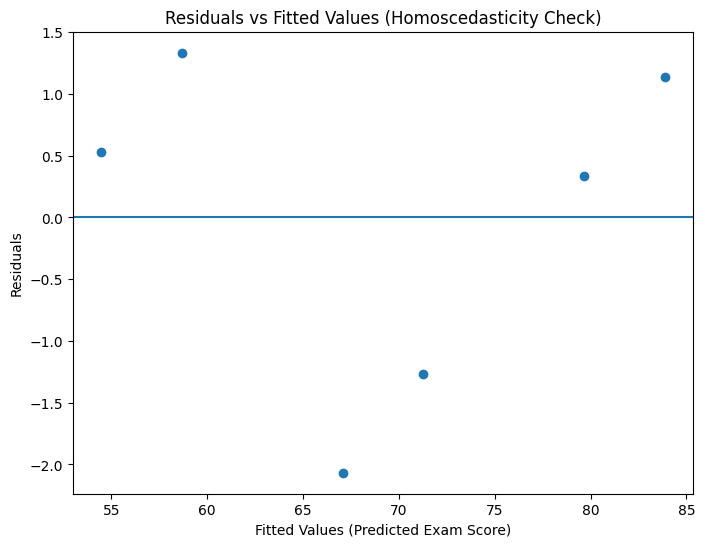

In [96]:
plt.figure(figsize=(8,6))
plt.scatter(fitted_values, residuals)
plt.axhline(0)

plt.xlabel("Fitted Values (Predicted Exam Score)")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values (Homoscedasticity Check)")
plt.show()

The homoscedasticity factor (HF) is calculated as the ratio of variance of residuals at low fitted values to high fitted values.
Since HF < 2, the variance of residuals is reasonably constant. Hence, the model satisfies the homoscedasticity assumption.